# 04 — VAR Model (Vector Autoregression)

**Goal:** Model **multiple time series together** — pollutants + weather variables influencing each other.

### Why VAR?
ARIMA/SARIMA model one variable at a time. But from Notebook 01 we know:
- NO2 ↔ SO2: **0.77** correlation (both from combustion)
- NO2 ↔ O3: **-0.53** (traffic NO destroys ozone)
- O3 ↔ humidity: **-0.66** (dry sunny days = more ozone)

VAR captures these **cross-variable dynamics** — each variable is modeled as a function of its own lags AND lags of all other variables.

### Theory
For k variables and p lags:

$$\mathbf{y}_t = \mathbf{c} + \mathbf{A}_1 \mathbf{y}_{t-1} + \mathbf{A}_2 \mathbf{y}_{t-2} + \cdots + \mathbf{A}_p \mathbf{y}_{t-p} + \mathbf{u}_t$$

Where $\mathbf{y}_t$ is a vector of all variables at time t, and $\mathbf{A}_i$ are coefficient matrices.

In [1]:
import sqlite3
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

SAVED_DIR = "saved"
os.makedirs(SAVED_DIR, exist_ok=True)

print("All imports loaded ✓")

All imports loaded ✓


## 1. Load Data & Select Variables

Shape: (1752, 6)
Variables: ['no2', 'o3', 'so2', 'temperature', 'humidity', 'windspeed']


,no2,o3,so2,temperature,humidity,windspeed
count,1752.00,1752.00,1752.00,1752.00,1752.00,1752.00
mean,46.68,27.99,2.39,11.27,78.70,14.91
std,18.23,16.04,1.81,5.56,9.71,6.41
min,6.85,1.11,-2.33,-4.78,36.71,3.00
25%,33.60,16.17,1.10,7.11,71.82,9.98
50%,45.66,25.15,2.00,10.93,79.90,13.85
75%,58.18,37.59,3.32,15.80,86.46,18.82
max,118.97,91.93,12.33,29.08,97.21,45.04


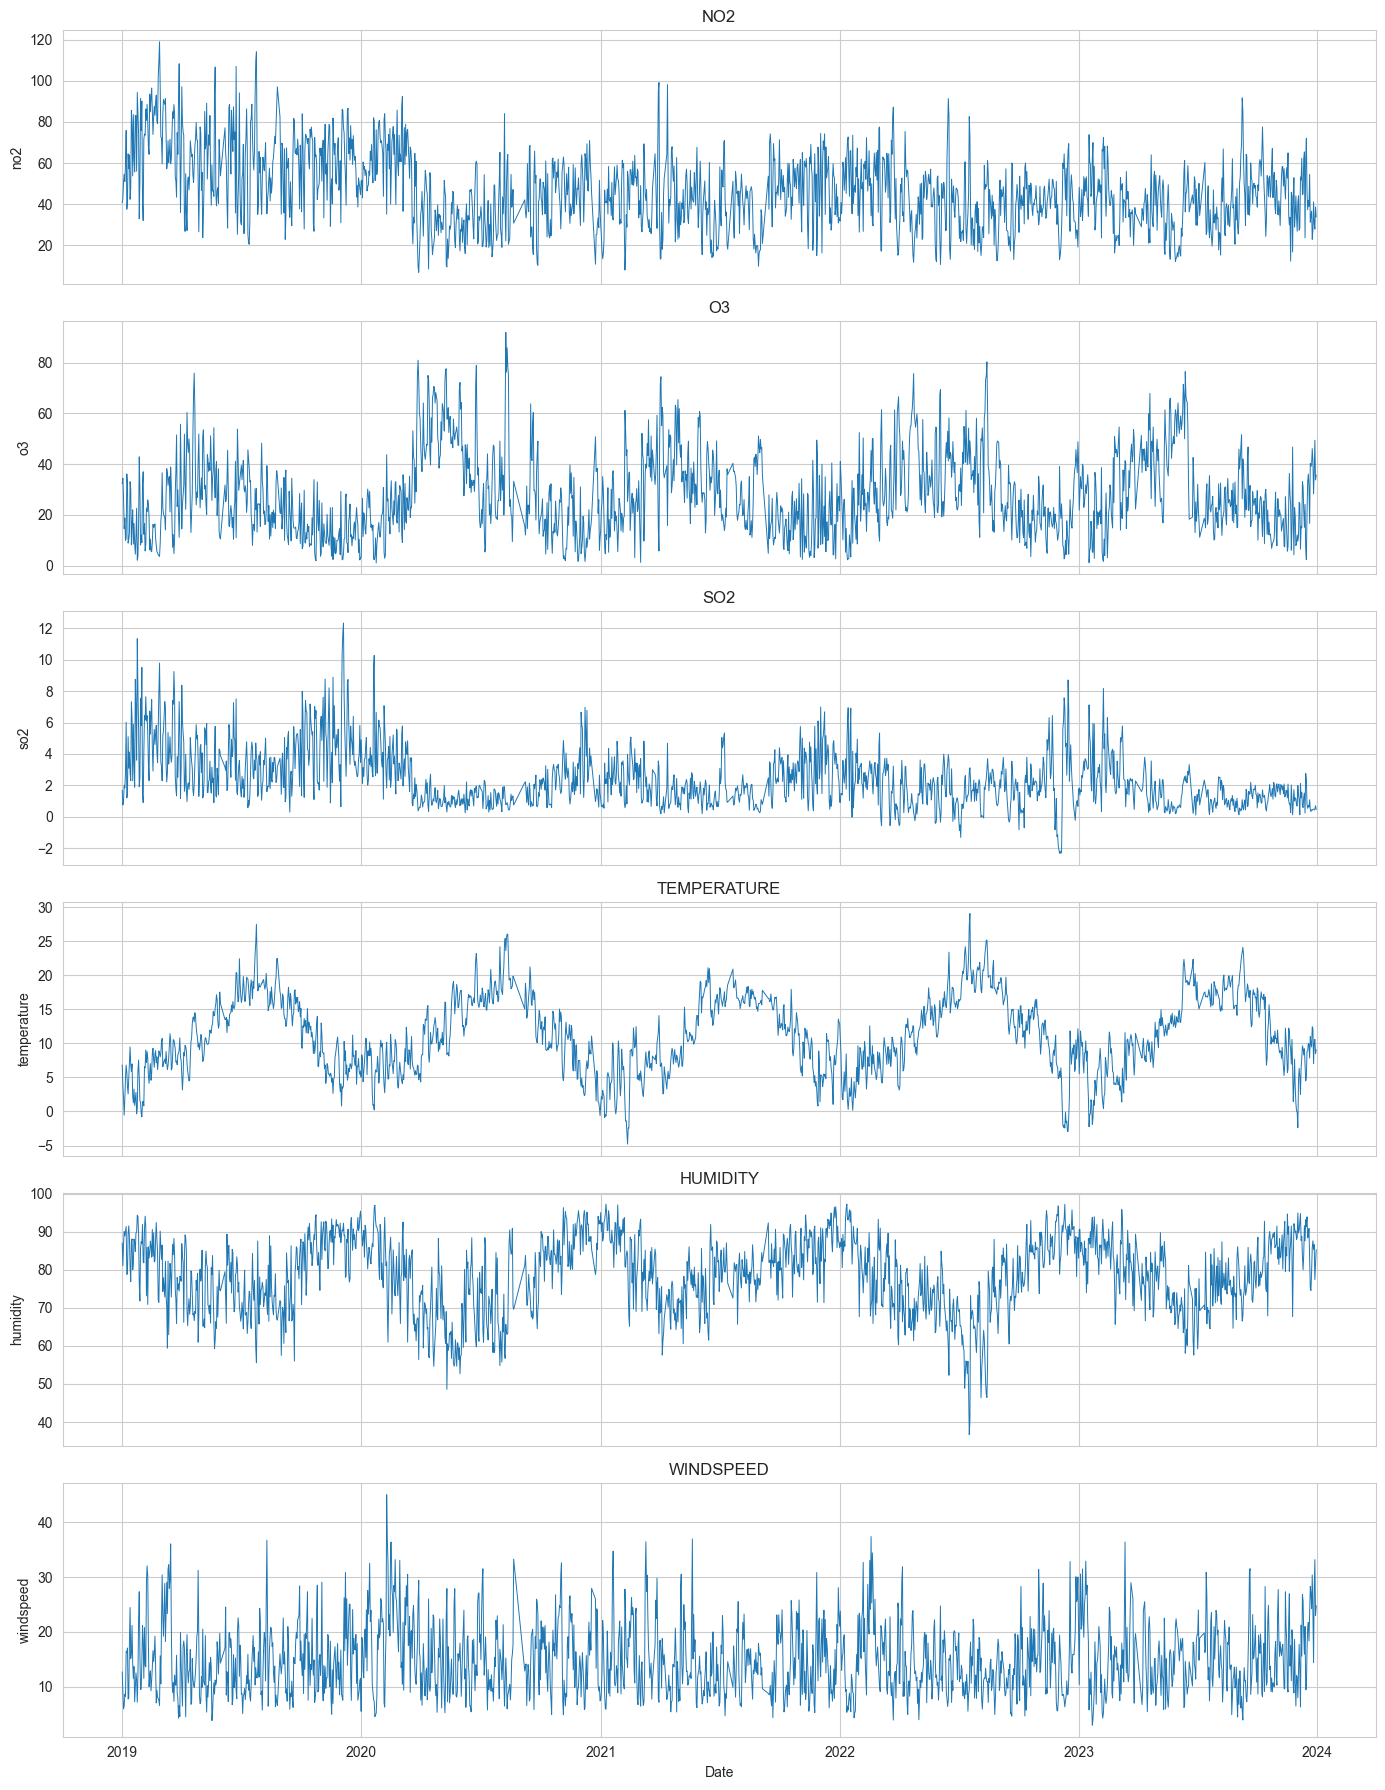

In [2]:
DB_PATH = "../database/air_quality.db"
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM clean_daily_my1", conn, parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)
conn.close()

# Select variables for VAR: pollutants + key weather variables
# From correlation heatmap: temperature, windspeed, humidity were most correlated
var_cols = ["no2", "o3", "so2", "temperature", "humidity", "windspeed"]
data = df[var_cols].copy()

print(f"Shape: {data.shape}")
print(f"Variables: {var_cols}")
display(data.describe().round(2))

# Plot all variables
fig, axes = plt.subplots(len(var_cols), 1, figsize=(14, 3*len(var_cols)), sharex=True)
for ax, col in zip(axes, var_cols):
    ax.plot(data.index, data[col], linewidth=0.7)
    ax.set_ylabel(col)
    ax.set_title(col.upper())
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 2. Stationarity Check — VAR Requires All Variables to be Stationary

In [3]:
# ADF test on all variables (level and differenced)
print("ADF Test — Stationarity Check\n")
print(f"{'Variable':<15} {'Level p-value':<18} {'Level':<18} {'Diff p-value':<18} {'Diff'}")
print("-" * 85)

for col in var_cols:
    # Level
    adf_level = adfuller(data[col], autolag="AIC")
    level_verdict = "✓ Stationary" if adf_level[1] < 0.05 else "✗ Non-stationary"
    
    # First difference
    adf_diff = adfuller(data[col].diff().dropna(), autolag="AIC")
    diff_verdict = "✓ Stationary" if adf_diff[1] < 0.05 else "✗ Non-stationary"
    
    print(f"{col:<15} {adf_level[1]:<18.6f} {level_verdict:<18} {adf_diff[1]:<18.6f} {diff_verdict}")

# Difference the data to ensure stationarity
data_diff = data.diff().dropna()
print(f"\nDifferenced data shape: {data_diff.shape}")

ADF Test — Stationarity Check

Variable        Level p-value      Level              Diff p-value       Diff
-------------------------------------------------------------------------------------
no2             0.004000           ✓ Stationary       0.000000           ✓ Stationary
o3              0.003306           ✓ Stationary       0.000000           ✓ Stationary
so2             0.013247           ✓ Stationary       0.000000           ✓ Stationary
temperature     0.055934           ✗ Non-stationary   0.000000           ✓ Stationary
humidity        0.000032           ✓ Stationary       0.000000           ✓ Stationary
windspeed       0.000000           ✓ Stationary       0.000000           ✓ Stationary

Differenced data shape: (1751, 6)


## 3. Granger Causality — Does One Variable Help Predict Another?

Granger causality tests whether **past values of X** improve the prediction of **Y** beyond Y's own past.
- H₀: X does NOT Granger-cause Y
- If p < 0.05 → X **does** help predict Y

Granger Causality Test (maxlag=7)



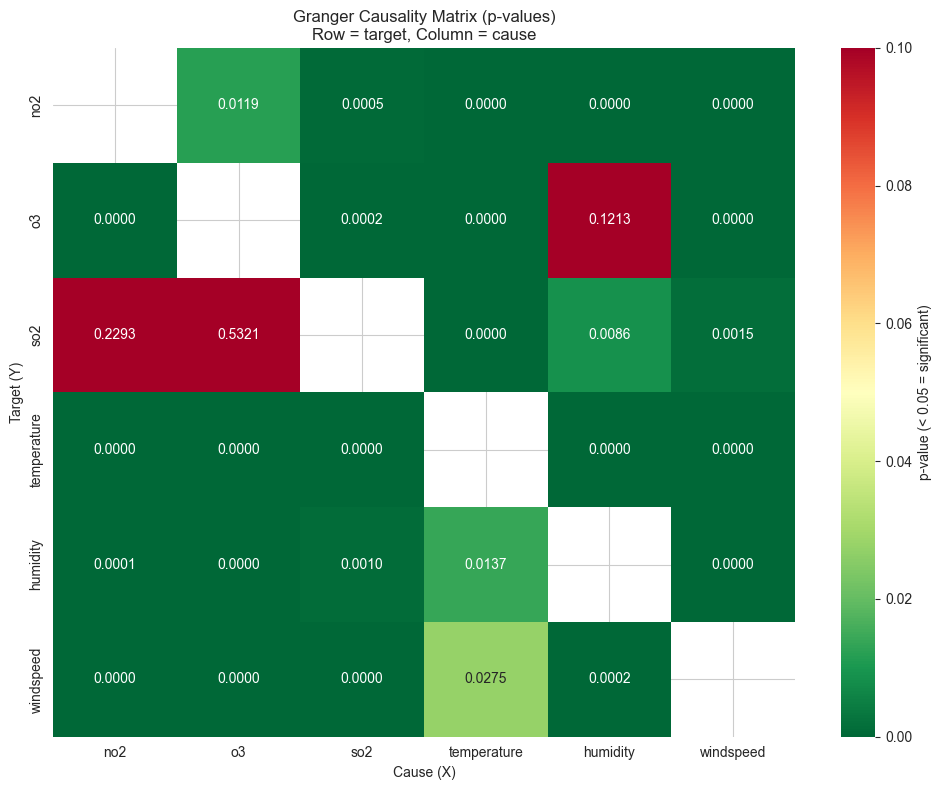


Significant Granger-causal relationships (p < 0.05):
  o3 → no2  (p=0.0119)
  so2 → no2  (p=0.0005)
  temperature → no2  (p=0.0000)
  humidity → no2  (p=0.0000)
  windspeed → no2  (p=0.0000)
  no2 → o3  (p=0.0000)
  so2 → o3  (p=0.0002)
  temperature → o3  (p=0.0000)
  windspeed → o3  (p=0.0000)
  temperature → so2  (p=0.0000)
  humidity → so2  (p=0.0086)
  windspeed → so2  (p=0.0015)
  no2 → temperature  (p=0.0000)
  o3 → temperature  (p=0.0000)
  so2 → temperature  (p=0.0000)
  humidity → temperature  (p=0.0000)
  windspeed → temperature  (p=0.0000)
  no2 → humidity  (p=0.0001)
  o3 → humidity  (p=0.0000)
  so2 → humidity  (p=0.0010)
  temperature → humidity  (p=0.0137)
  windspeed → humidity  (p=0.0000)
  no2 → windspeed  (p=0.0000)
  o3 → windspeed  (p=0.0000)
  so2 → windspeed  (p=0.0000)
  temperature → windspeed  (p=0.0275)
  humidity → windspeed  (p=0.0002)


In [4]:
# Granger causality matrix (using differenced data)
maxlag = 7
gc_matrix = pd.DataFrame(np.zeros((len(var_cols), len(var_cols))),
                          columns=var_cols, index=var_cols)

print(f"Granger Causality Test (maxlag={maxlag})\n")
for target in var_cols:
    for cause in var_cols:
        if target == cause:
            gc_matrix.loc[target, cause] = np.nan
            continue
        try:
            test_result = grangercausalitytests(
                data_diff[[target, cause]], maxlag=maxlag, verbose=False
            )
            # Get minimum p-value across all lags
            min_p = min(test_result[lag][0]["ssr_ftest"][1] for lag in range(1, maxlag+1))
            gc_matrix.loc[target, cause] = round(min_p, 4)
        except:
            gc_matrix.loc[target, cause] = np.nan

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = gc_matrix.isna()
sns.heatmap(gc_matrix.astype(float), annot=True, fmt=".4f", cmap="RdYlGn_r",
            mask=mask, ax=ax, vmin=0, vmax=0.1,
            cbar_kws={"label": "p-value (< 0.05 = significant)"})
ax.set_title("Granger Causality Matrix (p-values)\nRow = target, Column = cause")
ax.set_ylabel("Target (Y)")
ax.set_xlabel("Cause (X)")
plt.tight_layout()
plt.show()

# Summarize significant relationships
print("\nSignificant Granger-causal relationships (p < 0.05):")
for target in var_cols:
    for cause in var_cols:
        if target != cause:
            p = gc_matrix.loc[target, cause]
            if not np.isnan(p) and p < 0.05:
                print(f"  {cause} → {target}  (p={p:.4f})")

## 4. Train/Test Split & Lag Order Selection

In [5]:
# Same 90-day test split
TEST_SIZE = 90

train_diff = data_diff[:-TEST_SIZE]
test_diff = data_diff[-TEST_SIZE:]
train_raw = data[:-TEST_SIZE]
test_raw = data[-TEST_SIZE:]

print(f"Train (diff): {len(train_diff)} days")
print(f"Test  (diff): {len(test_diff)} days")

# Optimal lag selection using AIC/BIC
model = VAR(train_diff)
lag_results = model.select_order(maxlags=15)
print(f"\nLag Order Selection:")
display(lag_results.summary())

Train (diff): 1661 days
Test  (diff): 90 days

Lag Order Selection:


,AIC,BIC,FPE,HQIC
0,17.67,17.69,4.715e+07,17.68
1,17.24,17.38,3.085e+07,17.30
2,17.00,17.26,2.423e+07,17.10
3,16.87,17.24,2.120e+07,17.01
4,16.74,17.23,1.862e+07,16.92
5,16.61,17.22*,1.635e+07,16.84
6,16.56,17.29,1.551e+07,16.83*
7,16.55,17.40,1.548e+07,16.87
8,16.55,17.52,1.547e+07,16.91
9,16.57,17.65,1.572e+07,16.97


## 5. Fit VAR Model

In [6]:
# Fit VAR with optimal lag (or load from cache)
MODEL_PATH = os.path.join(SAVED_DIR, "var_fit.pkl")

best_lag = lag_results.aic
print(f"Best lag (AIC): {best_lag}")

if os.path.exists(MODEL_PATH):
    var_fit = pickle.load(open(MODEL_PATH, "rb"))
    print(f"✓ Loaded cached VAR model from {MODEL_PATH}")
else:
    var_model = VAR(train_diff)
    var_fit = var_model.fit(best_lag)
    pickle.dump(var_fit, open(MODEL_PATH, "wb"))
    print(f"✓ Trained and saved VAR({best_lag}) to {MODEL_PATH}")

print(f"\nVAR({var_fit.k_ar}) Summary:")
print(f"  Variables: {var_fit.names}")
print(f"  Lags: {var_fit.k_ar}")
print(f"  AIC: {var_fit.aic:.2f}")
print(f"  BIC: {var_fit.bic:.2f}")

Best lag (AIC): 12
✓ Trained and saved VAR(12) to saved/var_fit.pkl

VAR(12) Summary:
  Variables: ['no2', 'o3', 'so2', 'temperature', 'humidity', 'windspeed']
  Lags: 12
  AIC: 16.56
  BIC: 17.99


## 6. Impulse Response Functions (IRF)

IRF shows: if one variable gets a **shock** (sudden increase), how do all other variables respond over time?

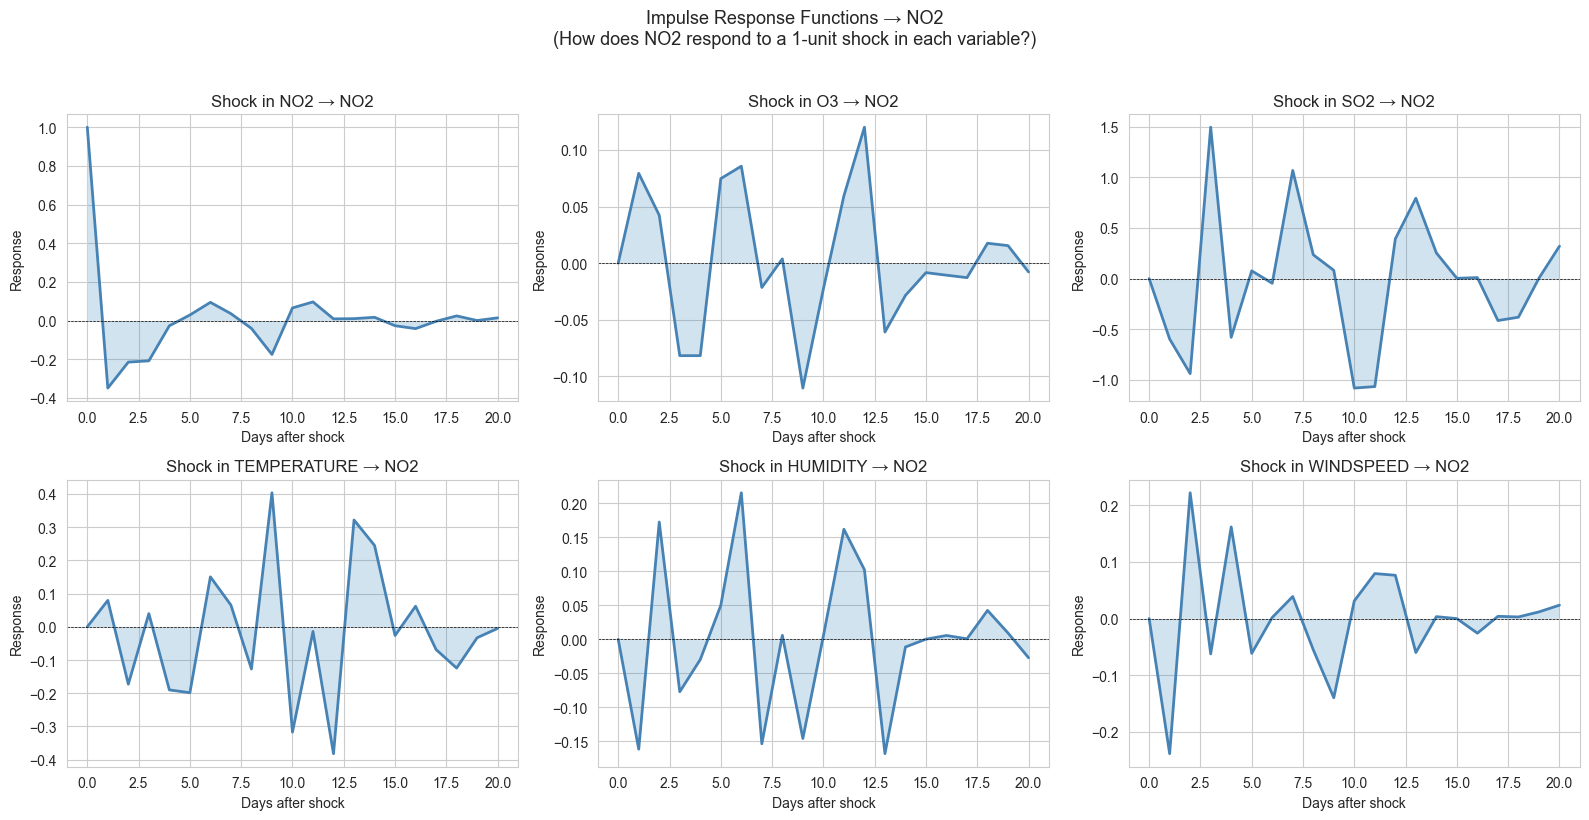

In [8]:
# Impulse Response Functions
irf = var_fit.irf(periods=20)

# Plot IRF: how does NO2 respond to a shock in each variable?
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for idx, col in enumerate(var_cols):
    ax = axes[idx // 3, idx % 3]
    irf_vals = irf.irfs[:, var_cols.index("no2"), var_cols.index(col)]
    ax.plot(irf_vals, linewidth=2, color="steelblue")
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(f"Shock in {col.upper()} → NO2")
    ax.set_xlabel("Days after shock")
    ax.set_ylabel("Response")
    ax.fill_between(range(len(irf_vals)), irf_vals, alpha=0.2)

fig.suptitle("Impulse Response Functions → NO2\n(How does NO2 respond to a 1-unit shock in each variable?)", 
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Forecast Variance Decomposition (FEVD)

FEVD shows: what **percentage of NO2's forecast error** is explained by each variable? This tells us which variables matter most for predicting NO2.

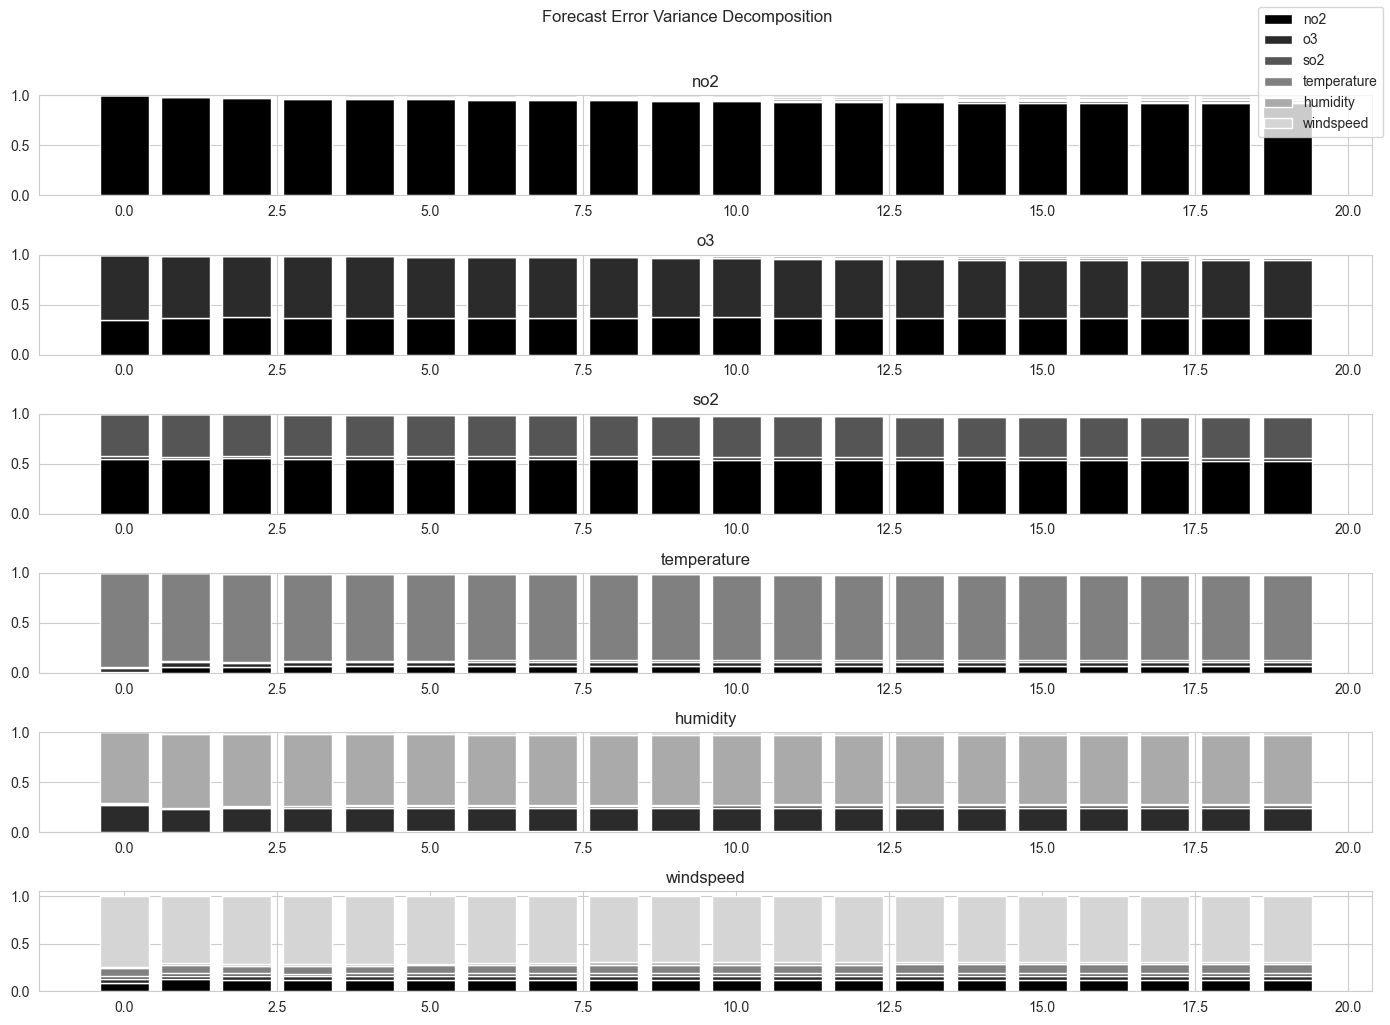

FEVD for NO2 — % of forecast error explained by each variable:



,no2,o3,so2,temperature,humidity,windspeed
Day 1,100.00,0.00,0.00,0.00,0.00,0.00
Day 5,96.43,0.79,0.98,0.03,0.50,1.26
Day 10,94.68,0.91,1.26,0.28,1.41,1.46
Day 15,92.91,1.04,1.89,0.65,1.95,1.56
Day 20,92.80,1.05,1.96,0.67,1.96,1.56


In [9]:
# Forecast Error Variance Decomposition
fevd = var_fit.fevd(periods=20)

# Plot FEVD for NO2
fig = fevd.plot(figsize=(14, 10))
plt.suptitle("Forecast Error Variance Decomposition", y=1.02)
plt.tight_layout()
plt.show()

# Print FEVD for NO2 at specific horizons
print("FEVD for NO2 — % of forecast error explained by each variable:\n")
fevd_no2 = fevd.decomp[var_cols.index("no2")]
fevd_df = pd.DataFrame(fevd_no2, columns=var_cols,
                        index=[f"Day {i+1}" for i in range(20)])
display(fevd_df.iloc[[0, 4, 9, 14, 19]].round(4) * 100)

## 8. Forecast & Evaluate

Since VAR works on differenced data, we need to **invert the differencing** to get back to original scale.

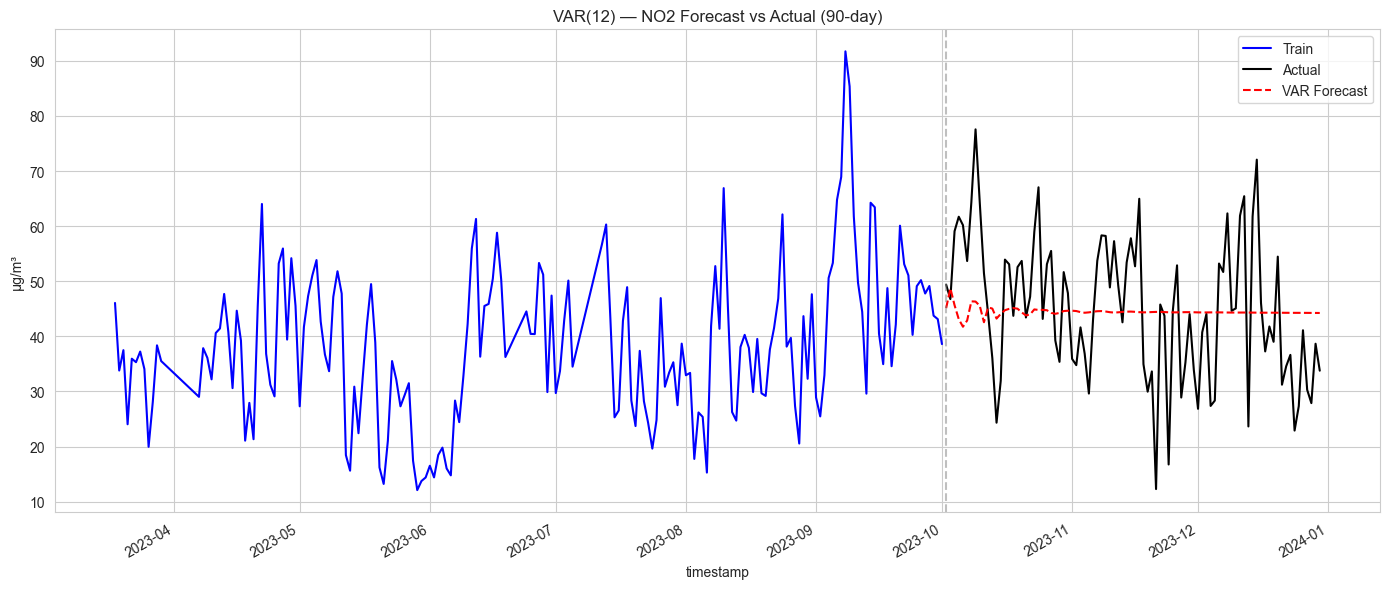

VAR Static Forecast (NO2):
  RMSE: 12.79 µg/m³
  MAE:  10.48 µg/m³
  MAPE: 23.3%


In [10]:
# Static forecast — predict all 90 days at once
lag_values = train_diff.values[-var_fit.k_ar:]
fc_diff = var_fit.forecast(lag_values, steps=TEST_SIZE)
fc_diff_df = pd.DataFrame(fc_diff, index=test_raw.index, columns=var_cols)

# Invert differencing: cumsum the diffs and add last known level
last_known = train_raw.iloc[-1]
fc_levels = fc_diff_df.cumsum() + last_known

# Plot NO2 forecast
fig, ax = plt.subplots(figsize=(14, 6))
train_raw["no2"][-180:].plot(ax=ax, label="Train", color="blue")
test_raw["no2"].plot(ax=ax, label="Actual", color="black", linewidth=1.5)
fc_levels["no2"].plot(ax=ax, label="VAR Forecast", color="red", linestyle="--")
ax.axvline(test_raw.index[0], color="gray", linestyle="--", alpha=0.5)
ax.set_title(f"VAR({var_fit.k_ar}) — NO2 Forecast vs Actual (90-day)")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

# Metrics for NO2
rmse = np.sqrt(mean_squared_error(test_raw["no2"], fc_levels["no2"]))
mae = mean_absolute_error(test_raw["no2"], fc_levels["no2"])
mape = mae / test_raw["no2"].mean() * 100
print(f"VAR Static Forecast (NO2):")
print(f"  RMSE: {rmse:.2f} µg/m³")
print(f"  MAE:  {mae:.2f} µg/m³")
print(f"  MAPE: {mape:.1f}%")

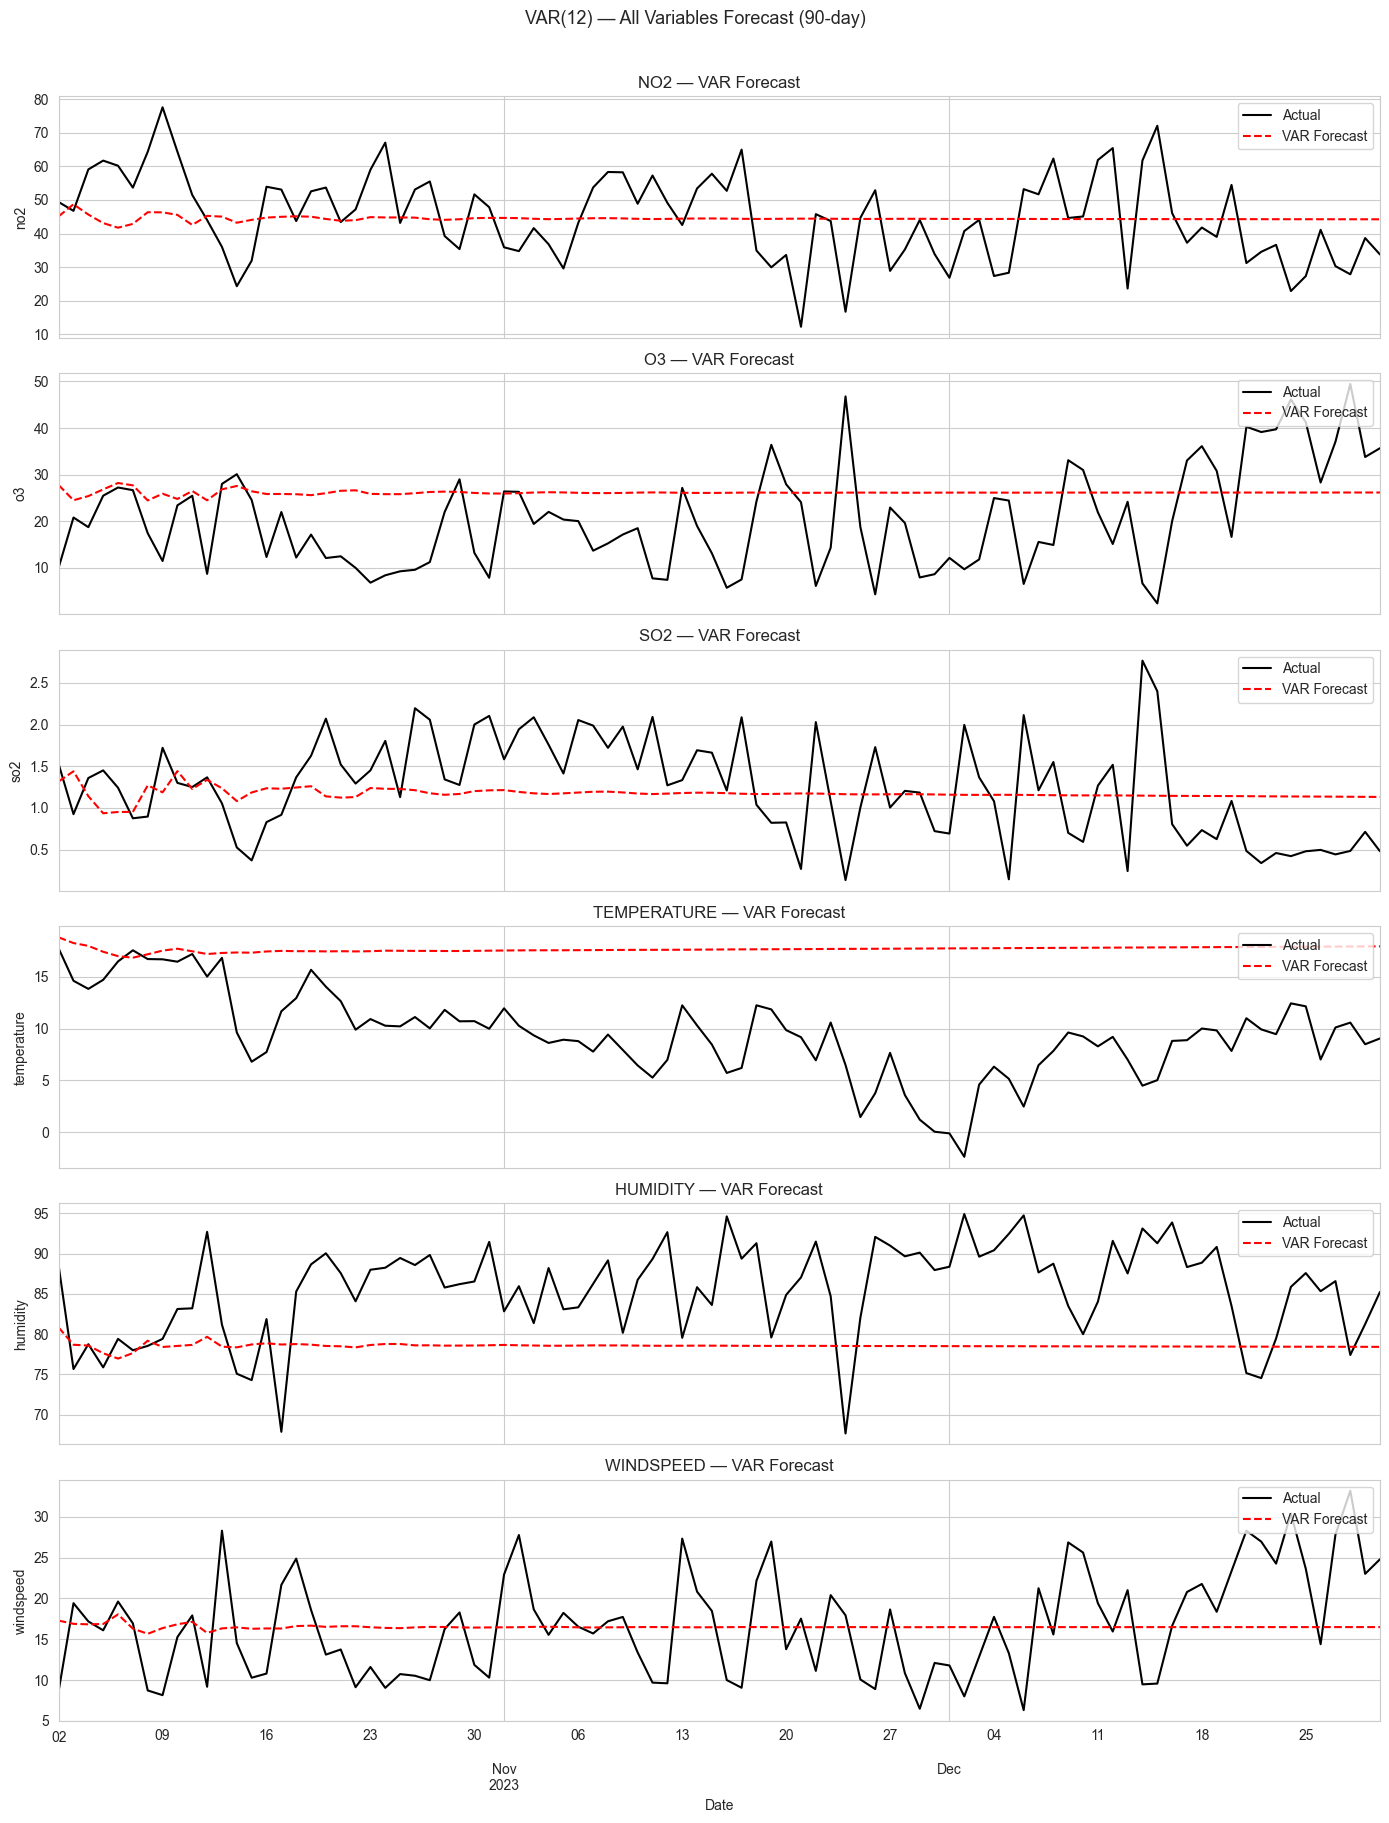


VAR(12) Static Forecast — All Variables:

Variable        RMSE       MAE        MAPE %    
---------------------------------------------
no2             12.79      10.48      23.3      
o3              12.13      10.16      49.6      
so2             0.59       0.49       39.5      
temperature     9.21       8.24       87.3      
humidity        8.91       7.82       9.2       
windspeed       6.32       5.22       31.1      


In [11]:
# Forecast all variables — plot everything
fig, axes = plt.subplots(len(var_cols), 1, figsize=(14, 3*len(var_cols)), sharex=True)

for ax, col in zip(axes, var_cols):
    test_raw[col].plot(ax=ax, label="Actual", color="black", linewidth=1.5)
    fc_levels[col].plot(ax=ax, label="VAR Forecast", color="red", linestyle="--")
    ax.set_ylabel(col)
    ax.set_title(f"{col.upper()} — VAR Forecast")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Date")
plt.suptitle(f"VAR({var_fit.k_ar}) — All Variables Forecast (90-day)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# Metrics for all variables
print(f"\nVAR({var_fit.k_ar}) Static Forecast — All Variables:\n")
print(f"{'Variable':<15} {'RMSE':<10} {'MAE':<10} {'MAPE %':<10}")
print("-" * 45)
for col in var_cols:
    r = np.sqrt(mean_squared_error(test_raw[col], fc_levels[col]))
    m = mean_absolute_error(test_raw[col], fc_levels[col])
    mp = m / test_raw[col].mean() * 100
    print(f"{col:<15} {r:<10.2f} {m:<10.2f} {mp:<10.1f}")

## 9. Walk-Forward Validation

  Step 30/90 done...
  Step 60/90 done...
  Step 90/90 done...

✓ Saved walk-forward predictions to saved/var_walkforward.pkl

Walk-Forward Results (NO2):
  RMSE: 31.14 µg/m³
  MAE:  24.17 µg/m³
  MAPE: 53.7%


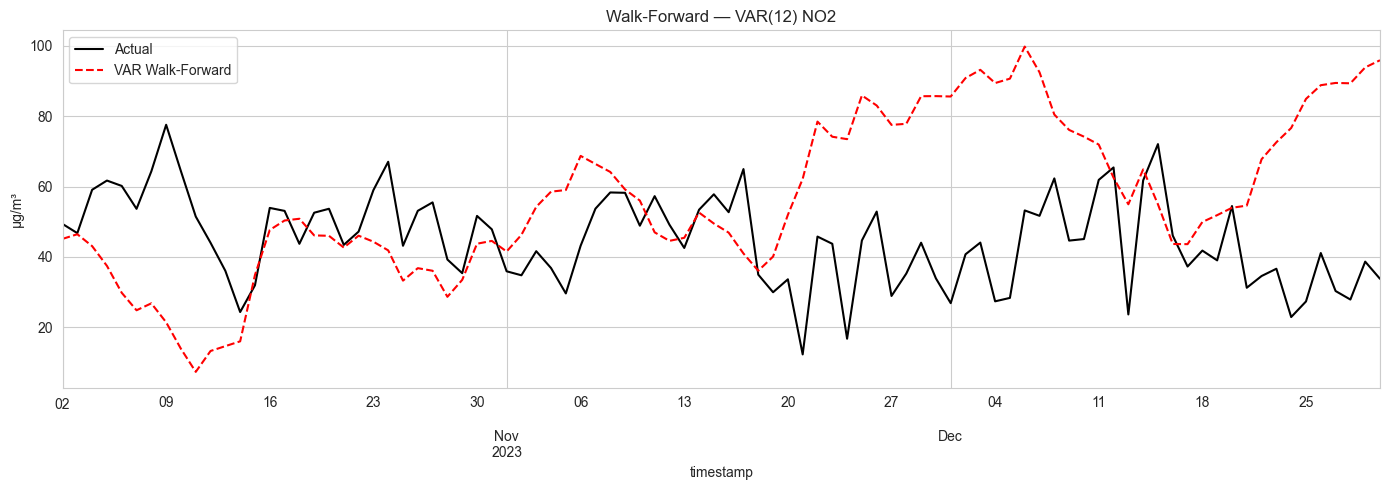

In [12]:
# Walk-forward validation (or load from cache)
WF_PATH = os.path.join(SAVED_DIR, "var_walkforward.pkl")

if os.path.exists(WF_PATH):
    wf_results = pd.read_pickle(WF_PATH)
    print(f"✓ Loaded cached walk-forward predictions from {WF_PATH}")
else:
    history_diff = data_diff[:-TEST_SIZE].values.tolist()
    history_raw = data[:-TEST_SIZE].values.tolist()
    predictions = []

    for i in range(TEST_SIZE):
        model = VAR(pd.DataFrame(history_diff, columns=var_cols))
        fitted = model.fit(var_fit.k_ar)

        lag_vals = np.array(history_diff[-fitted.k_ar:])
        fc = fitted.forecast(lag_vals, steps=1)[0]
        predictions.append(fc)

        # Add actual differenced value to history
        history_diff.append(data_diff.values[len(train_diff) + i])
        history_raw.append(data.values[len(train_raw) + i])

        if (i + 1) % 30 == 0:
            print(f"  Step {i+1}/{TEST_SIZE} done...")

    # Convert diff predictions to levels
    wf_diff = pd.DataFrame(predictions, index=test_raw.index, columns=var_cols)
    wf_results = pd.DataFrame(index=test_raw.index, columns=var_cols, dtype=float)

    for j, col in enumerate(var_cols):
        level = train_raw[col].iloc[-1]
        for k in range(len(wf_diff)):
            level = level + wf_diff.iloc[k][col]
            wf_results.iloc[k, j] = level

    wf_results.to_pickle(WF_PATH)
    print(f"\n✓ Saved walk-forward predictions to {WF_PATH}")

# Metrics for NO2
wf_rmse = np.sqrt(mean_squared_error(test_raw["no2"], wf_results["no2"].astype(float)))
wf_mae = mean_absolute_error(test_raw["no2"], wf_results["no2"].astype(float))
wf_mape = wf_mae / test_raw["no2"].mean() * 100

print(f"\nWalk-Forward Results (NO2):")
print(f"  RMSE: {wf_rmse:.2f} µg/m³")
print(f"  MAE:  {wf_mae:.2f} µg/m³")
print(f"  MAPE: {wf_mape:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
test_raw["no2"].plot(ax=ax, label="Actual", color="black", linewidth=1.5)
wf_results["no2"].astype(float).plot(ax=ax, label="VAR Walk-Forward", color="red", linestyle="--")
ax.set_title(f"Walk-Forward — VAR({var_fit.k_ar}) NO2")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

## 10. All Models Comparison — ARIMA vs SARIMA vs VAR

In [13]:
# All models comparison
comparison = pd.DataFrame({
    "Model": [
        "ARIMA(1,1,2) — Static",
        "ARIMA(1,1,2) — Walk-forward",
        "SARIMA(1,1,2)(1,1,2,7) — Static",
        "SARIMA(1,1,2)(1,1,2,7) — Walk-forward",
        f"VAR({var_fit.k_ar}) — Static",
        f"VAR({var_fit.k_ar}) — Walk-forward",
    ],
    "RMSE": [12.92, 11.61, 13.83, 11.97, rmse, wf_rmse],
    "MAE": [10.64, 9.31, 11.30, 9.50, mae, wf_mae],
    "MAPE (%)": [23.6, 20.7, 25.1, 21.1, mape, wf_mape],
})
display(comparison)

# Find best model dynamically
best_static = comparison[comparison["Model"].str.contains("Static")].sort_values("RMSE").iloc[0]
best_wf = comparison[comparison["Model"].str.contains("Walk-forward")].sort_values("RMSE").iloc[0]

print("\n" + "="*60)
print("KEY TAKEAWAYS (based on actual results)")
print("="*60)
print(f"• VAR({var_fit.k_ar}) models {len(var_cols)} variables simultaneously")
print(f"• Granger causality reveals which variables actually help predict NO2")
print(f"• IRF shows how shocks propagate across the system")
print(f"• FEVD quantifies how much each variable contributes to NO2 forecast error")
print(f"• VAR static RMSE: {rmse:.2f} vs ARIMA: 12.92 vs SARIMA: 13.83")
print(f"• VAR walk-forward RMSE: {wf_rmse:.2f} vs ARIMA: 11.61 vs SARIMA: 11.97")
print(f"• Best static model: {best_static['Model']} (RMSE: {best_static['RMSE']:.2f})")
print(f"• Best walk-forward model: {best_wf['Model']} (RMSE: {best_wf['RMSE']:.2f})")
print(f"• → Next: GARCH (Notebook 05) will model volatility/changing variance")

,Model,RMSE,MAE,MAPE (%)
0,"ARIMA(1,1,2) — Static",12.920000,10.640000,23.600000
1,"ARIMA(1,1,2) — Walk-forward",11.610000,9.310000,20.700000
2,"SARIMA(1,1,2)(1,1,2,7) — Static",13.830000,11.300000,25.100000
3,"SARIMA(1,1,2)(1,1,2,7) — Walk-forward",11.970000,9.500000,21.100000
4,VAR(12) — Static,12.793029,10.476771,23.271725
5,VAR(12) — Walk-forward,31.137868,24.167733,53.683035



KEY TAKEAWAYS (based on actual results)
• VAR(12) models 6 variables simultaneously
• Granger causality reveals which variables actually help predict NO2
• IRF shows how shocks propagate across the system
• FEVD quantifies how much each variable contributes to NO2 forecast error
• VAR static RMSE: 12.79 vs ARIMA: 12.92 vs SARIMA: 13.83
• VAR walk-forward RMSE: 31.14 vs ARIMA: 11.61 vs SARIMA: 11.97
• Best static model: VAR(12) — Static (RMSE: 12.79)
• Best walk-forward model: ARIMA(1,1,2) — Walk-forward (RMSE: 11.61)
• → Next: GARCH (Notebook 05) will model volatility/changing variance
